## 전세 평당 전세금 예측 모델

- 서울 전세 데이터를 분석하고 **평당 전세금**을 예측하는 머신러닝 모델 제작
- **타겟 변수**: 평당 전세금 (만원)
- **계산 공식**: 전세금 / 전용면적(평)

---
## 1. 라이브러리 임포트

In [1]:
# 데이터 처리
import pandas as pd
import numpy as np
import re

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 머신러닝
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

print("✅ 라이브러리 임포트 완료")

✅ 라이브러리 임포트 완료


---
## 2️. 한글 폰트 설정 (그래프용)

In [2]:
# Windows 환경에서 한글 깨짐 방지
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

print("✅ 한글 폰트 설정 완료")

✅ 한글 폰트 설정 완료


---
## 3️. 데이터 로드

통합 CSV 파일에서 **전세 데이터만** 필터링합니다.

In [3]:
# CSV 파일 경로 (각자 환경에 맞게 수정)
data_path = "C:\\dev\\SKN18-FINAL-1TEAM\\data\\통합.csv"

# 데이터 로드
df = pd.read_csv(data_path, encoding="utf-8")
print(f"전체 데이터: {len(df):,}건")

# 전세 데이터만 필터링
df_jeonse = df[df['거래_정보.거래방식'].str.contains('전세', na=False)].copy()
print(f"전세 데이터: {len(df_jeonse):,}건")

# 처음 5개 행 확인
# df_jeonse.head()

전체 데이터: 9,915건
전세 데이터: 1,965건


---
## 4️. 전세금 추출

"1억 2,000만원" 같은 한국어 금액을 **만원 단위 숫자**로 변환합니다.

In [4]:
def parse_korean_money(text):
    """
    한국 화폐 단위를 만원 단위 숫자로 변환
    예: "1억 2,000만원" -> 12000
    """
    if pd.isna(text):
        return 0
    
    # 불필요한 문자 제거
    text = text.replace(",", "").strip()
    text = re.sub(r"[^\d억만]", "", text)
    
    # "억" 단위 처리
    if "억" in text:
        parts = text.split("억")
        eok = int(parts[0]) if parts[0] else 0
        man = 0
        if len(parts) > 1 and "만" in parts[1]:
            man = int(parts[1].replace("만", ""))
        return eok * 10000 + man
    
    # 숫자만 있는 경우
    numbers = re.findall(r"\d+", text)
    if numbers:
        return int(numbers[0])
    
    return 0


# 전세금 추출
df_jeonse["전세금"] = df_jeonse["거래_정보.거래방식"].apply(parse_korean_money)

print(f"전세금 범위: {df_jeonse['전세금'].min():,.0f} ~ {df_jeonse['전세금'].max():,.0f} 만원")
print(f"평균 전세금: {df_jeonse['전세금'].mean():,.0f} 만원")

전세금 범위: 2,500 ~ 170,000 만원
평균 전세금: 21,092 만원


---
## 5️. 전용면적 추출 및 평당 전세금 계산

### 단계:
1. "30m2/38.68m2" → 전용면적 30㎡ 추출
2. ㎡를 평으로 변환 (1평 = 3.3㎡)
3. **평당 전세금 = 전세금 / 전용면적(평)**

In [5]:
def extract_area(value):
    """
    전용/공급면적에서 전용면적(㎡)만 추출
    예: "30m2/38.68m2" -> 30.0
    """
    if pd.isna(value):
        return None
    try:
        text = str(value).replace(" ", "").strip()
        area_str = text.split('/')[0].replace("m2", "")
        return float(area_str)
    except:
        return None


# 전용면적 추출 및 변환
df_jeonse["전용면적_m2"] = df_jeonse["매물_정보.전용/공급면적"].apply(extract_area)
df_jeonse["전용면적_평"] = df_jeonse["전용면적_m2"] / 3.3

# 평당 전세금 계산 (타겟 변수)
df_jeonse["평당가"] = df_jeonse["전세금"] / df_jeonse["전용면적_평"].replace(0, np.nan)

# 결측치 및 0 이하 값 제거
df_jeonse = df_jeonse.dropna(subset=["전용면적_평", "평당가"])
df_jeonse = df_jeonse[df_jeonse["평당가"] > 0]

print(f"유효 데이터: {len(df_jeonse):,}건")
print(f"평당 전세금 범위: {df_jeonse['평당가'].min():,.0f} ~ {df_jeonse['평당가'].max():,.0f} 만원")
print(f"평균 평당 전세금: {df_jeonse['평당가'].mean():,.0f} 만원")

유효 데이터: 1,961건
평당 전세금 범위: 333 ~ 22,685 만원
평균 평당 전세금: 2,688 만원


---
## 6️. 이상치 제거 (IQR 방법)

극단적으로 비정상적인 값을 제거하여 모델 성능을 향상시킵니다.

In [6]:
# IQR(사분위 범위) 계산
Q1 = df_jeonse['평당가'].quantile(0.25)
Q3 = df_jeonse['평당가'].quantile(0.75)
IQR = Q3 - Q1

# 이상치 범위 설정
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 제거
before_count = len(df_jeonse)
df_jeonse = df_jeonse[
    (df_jeonse['평당가'] >= lower_bound) & 
    (df_jeonse['평당가'] <= upper_bound)
]
after_count = len(df_jeonse)

print(f"이상치 제거: {before_count:,}건 → {after_count:,}건 ({before_count - after_count}건 제거)")

이상치 제거: 1,961건 → 1,942건 (19건 제거)


---
## 7️. 추가 특성 추출

모델 학습에 사용할 특성들을 추출합니다.

In [7]:
# 1. 관리비 추출 ("관리비 5만원" -> 5)
def extract_management_fee(value):
    if pd.isna(value):
        return 0
    match = re.search(r'(\d+)\s*만원', str(value))
    return int(match.group(1)) if match else 0

df_jeonse["관리비"] = df_jeonse["거래_정보.관리비"].apply(extract_management_fee)


# 2. 층 정보 추출 ("3층/10층" -> 3)
def extract_floor(value):
    if pd.isna(value):
        return None
    parts = str(value).split('/')
    match = re.search(r'-?\d+', parts[0])
    return int(match.group(0)) if match else None

df_jeonse["층"] = df_jeonse["매물_정보.해당층/전체층"].apply(extract_floor)


# 3. 방/욕실 개수 추출
room_info = df_jeonse["매물_정보.방/욕실개수"].str.extract(r'(?P<방수>\d+)개/(?P<욕실수>\d+)개')
df_jeonse["방수"] = room_info["방수"].astype(float)
df_jeonse["욕실수"] = room_info["욕실수"].astype(float)


# 4. 구/동 추출
def extract_gu_dong(addr):
    if pd.isna(addr):
        return (None, None)
    addr = str(addr).strip()
    gu_match = re.search(r'(\S+구)', addr)
    dong_match = re.search(r'(\S+?\d*(동|가))', addr)
    gu = gu_match.group(1) if gu_match else None
    dong = dong_match.group(1) if dong_match else None
    return (gu, dong)

df_jeonse["구"], df_jeonse["동"] = zip(*df_jeonse["주소_정보.전체주소"].apply(extract_gu_dong))


# 결측치 제거
df_jeonse = df_jeonse.dropna(subset=["구", "동", "층", "방수", "욕실수"])

print(f"최종 데이터: {len(df_jeonse):,}건")

최종 데이터: 1,326건


---
## 8️. 데이터 시각화 (EDA)

### 8-1. 평당 전세금 분포

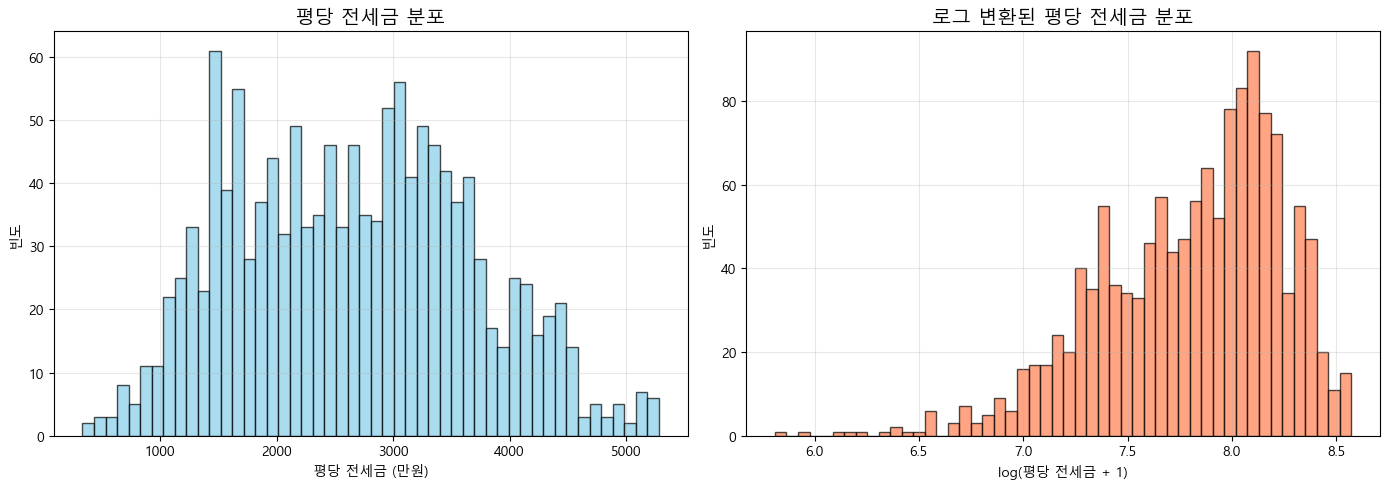

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원본 분포
axes[0].hist(df_jeonse["평당가"], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_title("평당 전세금 분포", fontsize=14)
axes[0].set_xlabel("평당 전세금 (만원)")
axes[0].set_ylabel("빈도")
axes[0].grid(True, alpha=0.3)

# 로그 변환 분포
axes[1].hist(np.log1p(df_jeonse["평당가"]), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title("로그 변환된 평당 전세금 분포", fontsize=14)
axes[1].set_xlabel("log(평당 전세금 + 1)")
axes[1].set_ylabel("빈도")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8-2. 구별 평균 평당 전세금 TOP 10

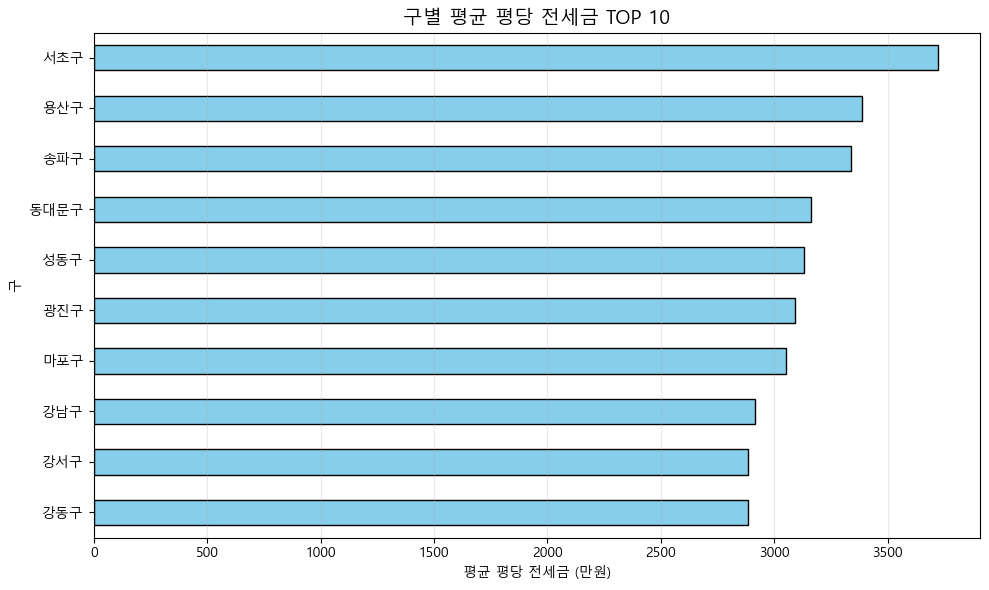


구별 평균 평당 전세금 TOP 10:
 1. 서초구: 3,722 만원
 2. 용산구: 3,387 만원
 3. 송파구: 3,338 만원
 4. 동대문구: 3,162 만원
 5. 성동구: 3,132 만원
 6. 광진구: 3,093 만원
 7. 마포구: 3,051 만원
 8. 강남구: 2,915 만원
 9. 강서구: 2,886 만원
10. 강동구: 2,885 만원


In [9]:
# 구별 평균 계산
gu_avg = df_jeonse.groupby("구")["평당가"].mean().sort_values(ascending=False).head(10)

# 막대 그래프
plt.figure(figsize=(10, 6))
gu_avg.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title("구별 평균 평당 전세금 TOP 10", fontsize=14)
plt.xlabel("평균 평당 전세금 (만원)")
plt.ylabel("구")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# 순위 출력
print("\n구별 평균 평당 전세금 TOP 10:")
for idx, (gu, price) in enumerate(gu_avg.items(), 1):
    print(f"{idx:2d}. {gu}: {price:,.0f} 만원")

---
## 9️, 특성 엔지니어링 (Feature Engineering)

모델 성능을 높이기 위한 추가 특성을 생성합니다.

In [10]:
# ===== 추가 중요 피처 생성 =====

# 5. 전체층수 추출 ("3층/10층" -> 10)
def extract_total_floor(value):
    if pd.isna(value):
        return None
    parts = str(value).split('/')
    if len(parts) < 2:
        return None
    match = re.search(r'\d+', parts[1])
    return int(match.group(0)) if match else None

df_jeonse["전체층수"] = df_jeonse["매물_정보.해당층/전체층"].apply(extract_total_floor)


In [11]:
# ===== 1. 옵션 개수 계산 (추가_옵션에서 추출) =====
def count_options(value):
    """
    추가_옵션 컬럼에서 옵션 개수 계산
    예: "엘리베이터|전세자금대출|주차가능" -> 3
    """
    if pd.isna(value):
        return 0
    
    # "|"로 분리하여 개수 계산
    options = str(value).split('|')
    # 빈 문자열 제거
    options = [opt.strip() for opt in options if opt.strip()]
    return len(options)

df_jeonse["옵션개수"] = df_jeonse["추가_옵션"].apply(count_options)


print("=" * 80)
print("✅ 특성 엔지니어링 완료")
print("=" * 80)
print(f"옵션개수 통계:")
print(f"  평균: {df_jeonse['옵션개수'].mean():.2f}개")
print(f"  중앙값: {df_jeonse['옵션개수'].median():.0f}개")
print(f"  최대: {df_jeonse['옵션개수'].max():.0f}개")
print(f"  0개인 매물: {(df_jeonse['옵션개수'] == 0).sum()}건")
print("=" * 80)

✅ 특성 엔지니어링 완료
옵션개수 통계:
  평균: 4.37개
  중앙값: 5개
  최대: 7개
  0개인 매물: 52건


---
## 10. ML용 데이터 준비

모델 학습에 사용할 특성만 선택합니다.

In [12]:
# ===== 5. ML용 데이터셋 구성 =====

# 타깃(평당가) 컬럼
target_col = "평당가"

# 사용할 피처 목록 (타깃은 제외)
feature_cols = [
    # 기본 특성
    "전용면적_평",
    "관리비",
    "방수",        
    "욕실수",      
    
    # 위치 특
    "구",
    "동",
    
    # 옵션 특성
    "옵션개수",
    
    # 층 관련 특성
    "층",        
]

# 타깃 + 피처 모두 있는 행만 사용 (결측치 제거)
df_ml = df_jeonse[[target_col] + feature_cols].dropna().copy()

print(f"ML 데이터 크기: {df_ml.shape}")
print(f"타깃 컬럼: {target_col}")
print(f"특성 개수: {len(feature_cols)}개")
print(f"데이터 개수: {len(df_ml):,}건")

ML 데이터 크기: (1326, 9)
타깃 컬럼: 평당가
특성 개수: 8개
데이터 개수: 1,326건


In [13]:
# X: 입력 특성, y: 타겟 변수
X = df_ml.drop(columns=["평당가"])
y = df_ml["평당가"]

# ===== LabelEncoder 적용 (월세 모델과 동일한 방식) =====
print("\n" + "=" * 80)
print("🔒 LabelEncoder 적용 (구, 동)")
print("=" * 80)

label_cols = ["구", "동"]

for col in label_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"✅ '{col}' 인코딩 완료: {X[col].nunique()}개 카테고리")

print("=" * 80)

# 80:20 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n학습 데이터: {len(X_train):,}건")
print(f"테스트 데이터: {len(X_test):,}건")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


🔒 LabelEncoder 적용 (구, 동)
✅ '구' 인코딩 완료: 27개 카테고리
✅ '동' 인코딩 완료: 140개 카테고리

학습 데이터: 1,060건
테스트 데이터: 266건
Train shape: (1060, 8)
Test shape: (266, 8)


---
## 1️1. 모델 학습 (XGBoost)

### 로그 변환
평당가의 분포가 치우쳐 있으므로 **로그 변환**을 통해 정규화합니다.

In [14]:
# 타겟 변수 로그 변환
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("✅ 로그 변환 완료")

✅ 로그 변환 완료


In [15]:
# XGBoost 모델 생성
model = XGBRegressor(
    n_estimators=1800,        # 트리 개수
    learning_rate=0.018,      # 학습률
    max_depth=10,             # 트리 최대 깊이
    subsample=0.88,           # 데이터 샘플링 비율
    colsample_bytree=0.88,    # 특성 샘플링 비율
    min_child_weight=3,       # 과적합 방지
    gamma=0.03,               # 노드 분할 최소 손실
    reg_alpha=0.03,           # L1 정규화
    reg_lambda=1,             # L2 정규화
    random_state=42,
    n_jobs=-1,                # 모든 CPU 코어 사용
    tree_method='hist'        # 빠른 학습 방법
)

# 모델 학습
print("\n🚀 모델 학습 시작...")
model.fit(X_train, y_train_log)
print("✅ 모델 학습 완료!")


🚀 모델 학습 시작...
✅ 모델 학습 완료!


---
## 1️2. 예측 및 평가

### 성능 지표:
- **MAE** (Mean Absolute Error): 평균 절대 오차
- **RMSE** (Root Mean Squared Error): 평균 제곱근 오차
- **R²** (R-squared): 결정계수 (1에 가까울수록 좋음)
- **MAPE** (Mean Absolute Percentage Error): 평균 절대 백분율 오차

In [16]:
# 예측 (로그 변환된 값)
y_pred_log = model.predict(X_test)

# 원래 스케일로 복원
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test_log)

# 성능 지표 계산
mae = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2 = r2_score(y_test_orig, y_pred)
mape = np.mean(np.abs((y_test_orig - y_pred) / y_test_orig)) * 100

# 결과 출력
print("\n" + "=" * 80)
print("📊 전세 평당 전세금 예측 모델 성능")
print("=" * 80)
print(f"MAE   : {mae:,.2f} 만원  (평균적으로 {mae:,.0f}만원 오차)")
print(f"RMSE  : {rmse:,.2f} 만원")
print(f"R²    : {r2:.4f}  (1에 가까울수록 좋음)")
print(f"MAPE  : {mape:.2f}%  (평균 {mape:.1f}% 오차율)")


📊 전세 평당 전세금 예측 모델 성능
MAE   : 372.03 만원  (평균적으로 372만원 오차)
RMSE  : 530.73 만원
R²    : 0.7346  (1에 가까울수록 좋음)
MAPE  : 20.03%  (평균 20.0% 오차율)


---
## 1️3. 결과 시각화

### 13-1. 실제값 vs 예측값

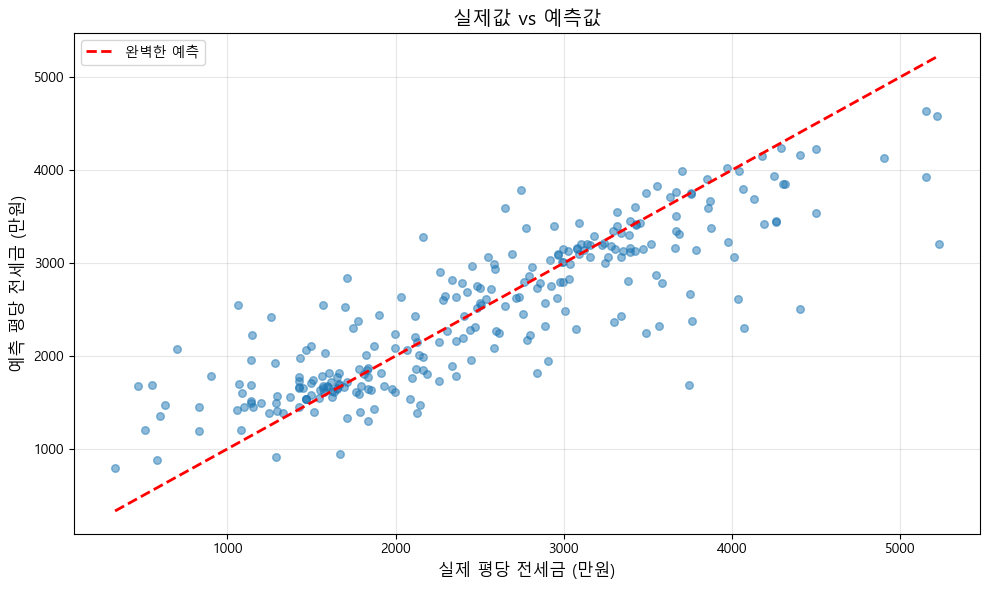

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, y_pred, alpha=0.5, s=30)

# 대각선 (완벽한 예측)
max_val = max(y_test_orig.max(), y_pred.max())
min_val = min(y_test_orig.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='완벽한 예측')

plt.xlabel("실제 평당 전세금 (만원)", fontsize=12)
plt.ylabel("예측 평당 전세금 (만원)", fontsize=12)
plt.title("실제값 vs 예측값", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 13-2. 오차율 분포

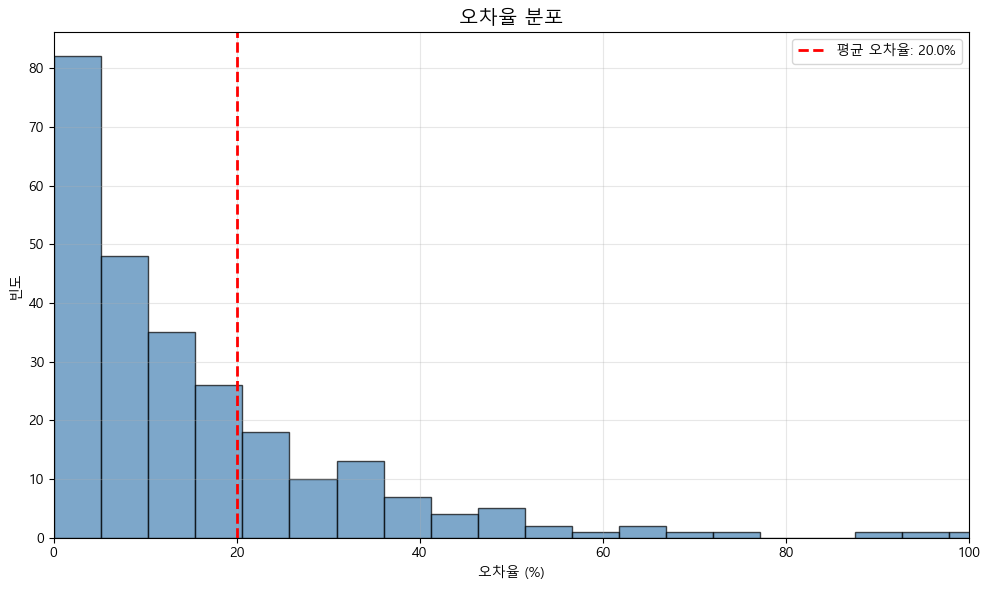

In [18]:
# 오차율 계산
error_rate = np.abs((y_test_orig - y_pred) / y_test_orig) * 100

plt.figure(figsize=(10, 6))
plt.hist(error_rate, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlim(0, 100)
plt.axvline(mape, color='red', linestyle='--', linewidth=2, 
            label=f'평균 오차율: {mape:.1f}%')
plt.title("오차율 분포", fontsize=14)
plt.xlabel("오차율 (%)")
plt.ylabel("빈도")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 13-3. 특성 중요도

C:\Users\Playdata\AppData\Local\Temp\ipykernel_9724\109552324.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='중요도', y='특성', palette='viridis')


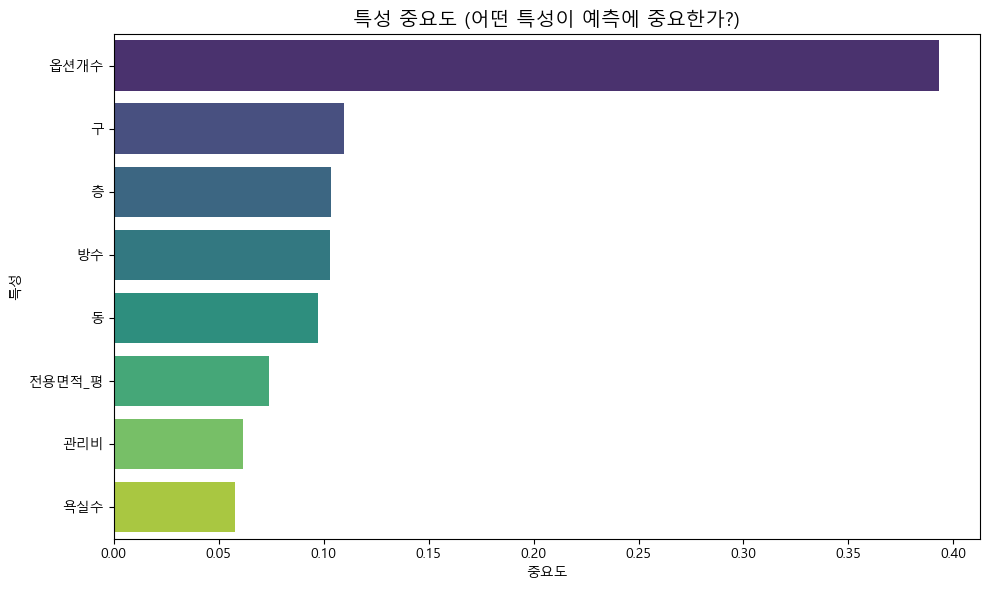


특성 중요도 순위:
옵션개수                 : 0.3930
구                    : 0.1095
층                    : 0.1036
방수                   : 0.1031
동                    : 0.0972
전용면적_평               : 0.0741
관리비                  : 0.0615
욕실수                  : 0.0580


In [19]:
# 특성 중요도 계산
feature_importance = pd.DataFrame({
    '특성': X.columns,
    '중요도': model.feature_importances_
}).sort_values('중요도', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='중요도', y='특성', palette='viridis')
plt.title("특성 중요도 (어떤 특성이 예측에 중요한가?)", fontsize=14)
plt.xlabel("중요도")
plt.ylabel("특성")
plt.tight_layout()
plt.show()

# 순위 출력
print("\n특성 중요도 순위:")
for idx, row in feature_importance.iterrows():
    print(f"{row['특성']:20s} : {row['중요도']:.4f}")

In [20]:
import shap

# SHAP Explainer 생성 (XGBoost 전용)
explainer = shap.TreeExplainer(model)

# 테스트 데이터에서 샘플링 (계산 속도를 위해 100개만 사용)
X_test_sample = X_test.sample(min(100, len(X_test)), random_state=42)

# SHAP 값 계산
print("🔍 SHAP 값 계산 중... (시간이 걸릴 수 있습니다)")
shap_values = explainer.shap_values(X_test_sample)
print("✅ SHAP 계산 완료!")

🔍 SHAP 값 계산 중... (시간이 걸릴 수 있습니다)
✅ SHAP 계산 완료!


#### SHAP Waterfall Plot (개별 예측 설명)

특정 샘플 하나를 선택하여 각 특성이 어떻게 기여했는지 자세히 봅니다.

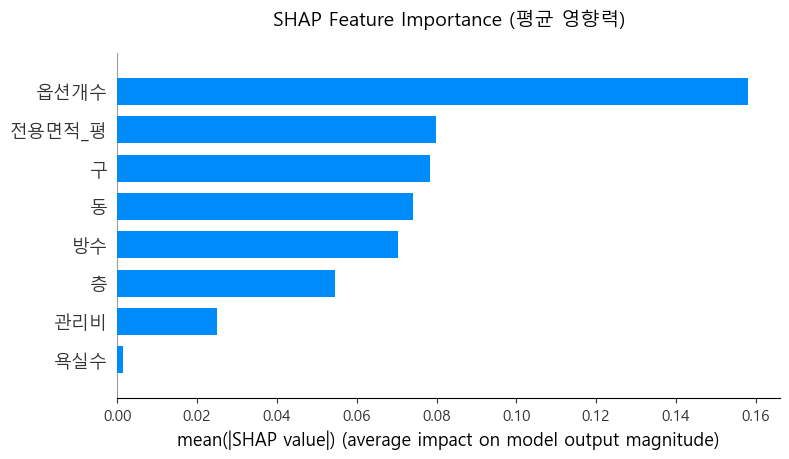

In [21]:
import shap
# SHAP Bar Plot (평균 절댓값)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (평균 영향력)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

#### SHAP Bar Plot (평균 중요도)

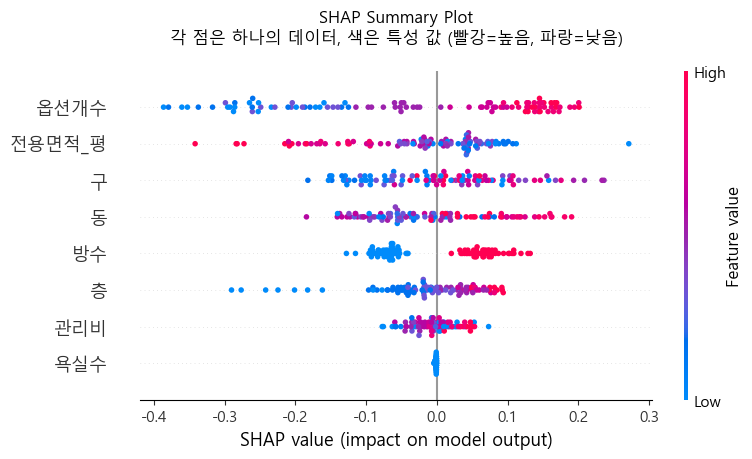


📖 해석 방법:
- 위에 있을수록 중요한 특성
- 오른쪽으로 퍼져있을수록 예측에 큰 영향
- 빨간색: 특성 값이 높을 때
- 파란색: 특성 값이 낮을 때


In [22]:
# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="dot", show=False)
plt.title("SHAP Summary Plot\n각 점은 하나의 데이터, 색은 특성 값 (빨강=높음, 파랑=낮음)", fontsize=12, pad=20)
plt.tight_layout()
plt.show()

print("\n📖 해석 방법:")
print("- 위에 있을수록 중요한 특성")
print("- 오른쪽으로 퍼져있을수록 예측에 큰 영향")
print("- 빨간색: 특성 값이 높을 때")
print("- 파란색: 특성 값이 낮을 때")

---
## 1️4. 예측 결과 샘플 확인

### 14-4. SHAP 분석 (고급 특성 중요도)

**SHAP (SHapley Additive exPlanations)**는 각 특성이 예측에 얼마나 기여했는지 설명하는 고급 해석 도구입니다.

- **특성 중요도 vs SHAP**: 
  - 특성 중요도는 전체적인 중요도
  - SHAP은 개별 예측마다 각 특성의 기여도를 보여줌

In [23]:
# 결과 데이터프레임 생성
df_result = pd.DataFrame({
    "실제 평당 전세금": y_test_orig.values[:20],
    "예측 평당 전세금": y_pred[:20],
    "오차": y_test_orig.values[:20] - y_pred[:20],
    "오차율(%)": error_rate.values[:20]
})

print("\n" + "=" * 80)
print("📋 예측 결과 샘플 (상위 20개)")
print("=" * 80)
print(df_result.to_string(index=False))
print("=" * 80)


📋 예측 결과 샘플 (상위 20개)
  실제 평당 전세금   예측 평당 전세금           오차     오차율(%)
1508.064516 1744.111694  -236.047178  15.652326
1832.829255 1851.727295   -18.898040   1.031086
2508.836279 2547.972900   -39.136622   1.559951
1060.491493 2553.207031 -1492.715538 140.756955
1780.821918 1861.421021   -80.599103   4.525950
1914.489964 1811.877686   102.612279   5.359771
1542.480066 1542.968872    -0.488806   0.031690
3634.361233 3707.779785   -73.418552   2.020123
 470.250000 1680.731079 -1210.481079 257.412244
 332.745147  790.175354  -457.430207 137.471639
2142.857143 1470.042236   672.814907  31.398029
5229.448663 3205.361816  2024.086847  38.705550
3566.282421 2320.121826  1246.160595  34.942847
3137.521222 3201.731201   -64.209979   2.046519
1995.967742 1612.976807   382.990935  19.188233
1995.967742 2236.625488  -240.657746  12.057196
5152.224824 3926.677490  1225.547334  23.786760
2125.000000 1390.590454   734.409546  34.560449
2975.409836 2799.061035   176.348801   5.926874
2357.142857 2630.86